El presente análisis tiene como objetivo identificar los factores que influyen en el abandono de clientes (churn) en una empresa de telecomunicaciones. A través de técnicas de análisis exploratorio de datos, se busca comprender el comportamiento de los clientes y detectar patrones que permitan mejorar la retención. Este análisis está dirigido a equipos de negocio y toma de decisiones.

# **CARGAR CSV**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/Data science II/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **LIMPIEZA DE DATOS**

Se realizó la conversión de variables a tipos numéricos y se eliminaron valores nulos para asegurar la calidad del análisis.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [5]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# **GRAFICOS**

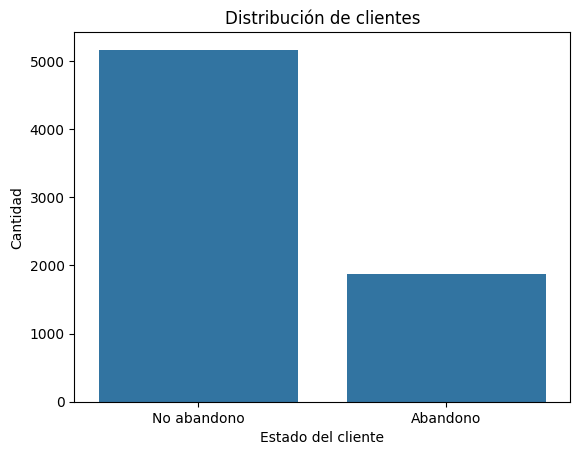

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title("Distribución de clientes")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad")

plt.xticks([0, 1], ["No abandono", "Abandono"])

plt.show()


**Se observa que la mayoría de los clientes no abandona el servicio, aunque existe un porcentaje significativo de churn que representa una oportunidad de mejora para la empresa.**

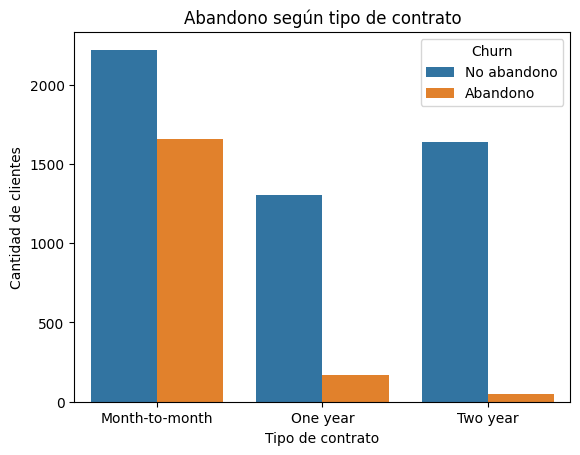

In [8]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Abandono según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.legend(title="Churn", labels=["No abandono", "Abandono"])

plt.show()


**Los clientes con contratos mensuales presentan una mayor tasa de abandono en comparación con aquellos que tienen contratos a largo plazo, lo que sugiere menor compromiso con el servicio.**

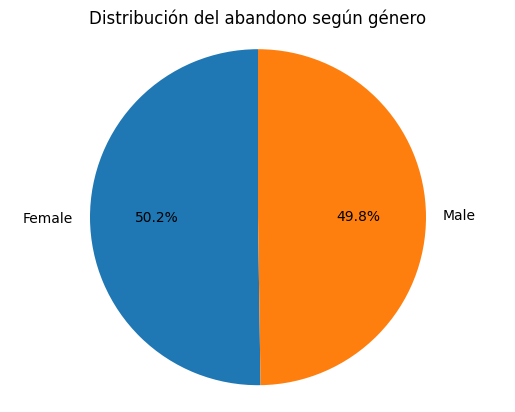

In [16]:
gender_churn = df[df['Churn'] == 1]['gender'].value_counts()

plt.figure()
plt.pie(gender_churn,
        labels=gender_churn.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribución del abandono según género")

plt.axis('equal')

plt.show()






**El abandono del servicio se distribuye de manera relativamente equilibrada entre géneros, lo que indica que este factor no tiene una influencia significativa en la decisión de los clientes.**

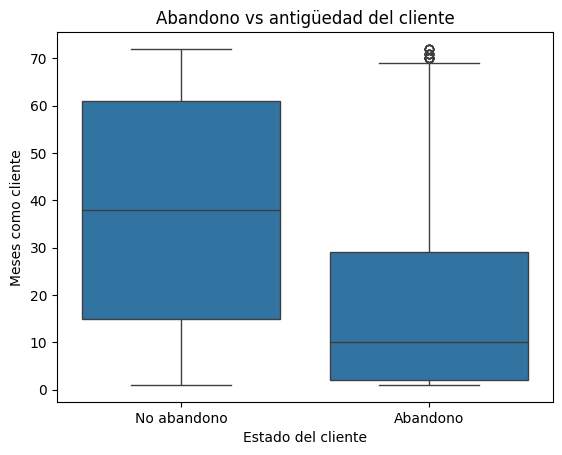

In [10]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Abandono vs antigüedad del cliente")
plt.xlabel("Estado del cliente")
plt.ylabel("Meses como cliente")

plt.xticks([0, 1], ["No abandono", "Abandono"])

plt.show()


**Los clientes con menor antigüedad presentan una mayor probabilidad de abandono, lo que indica que los primeros meses son críticos para la retención.**

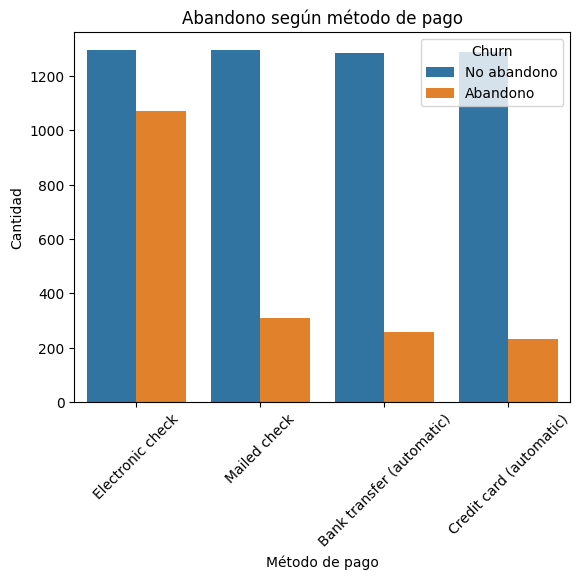

In [11]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title("Abandono según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.legend(title="Churn", labels=["No abandono", "Abandono"])

plt.show()


**Los clientes que utilizan ciertos métodos de pago presentan mayores tasas de abandono, lo que podría estar relacionado con la experiencia de pago o nivel de compromiso.**